# Truncated Policy Iteration implementation on Frozen Lake environment

This project implements **Value Iteration** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:

lake_grid = [["F", "F", "F", "F"],
             ["F", "H", "F", "H"],
             ["F", "H", "F", "H"],
             ["H", "F", "F", "G"]]

reward_points = {
    "S": -1,
    "G": 10,
    "F": -1,
    "H": -10
}

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

# Truncated Policy Iteration Algorithm Implementation

- The truncated policy iteration algorithm= is an extension of Value-iteration and Policy-iteration algorithm

## Policy iteration algorithm:  
- **step 1: policy evaluation**
    $$v_{\pi_k} = r_{\pi_k} + \gamma P_{\pi_k} v_{\pi_k}$$
    - solve above Bellman's equ iteratively using Contraction Mapping Theorem
- **step 2: policy improvement**
    $$\pi_{k+1} = \arg\max_{\pi} \left[ \mathcal{r}_\pi + \gamma \mathcal{P}_{\pi} v_{\pi_k} \right]$$


- In policy iteration, solving $v_{\pi_1} = r_{\pi_1} + \gamma P_{\pi_1} v_{\pi_1}$ requires iterative algorithm (an infinite number of iterations)

- Whereas, in value iteration, solving $v_{\pi_1} = r_{\pi_1} + \gamma P_{\pi_1} v_{\pi_0}$ is a one-step iteration

- In policy iteration, solving $v_{\pi_1} = r_{\pi_1} + \gamma P_{\pi_1} v_{\pi_1}$ requires iterative algorithm (an infinite number of iterations)

- Whereas, in value iteration, solving $v_{\pi_1} = r_{\pi_1} + \gamma P_{\pi_1} v_{\pi_0}$ is a one-step iteration

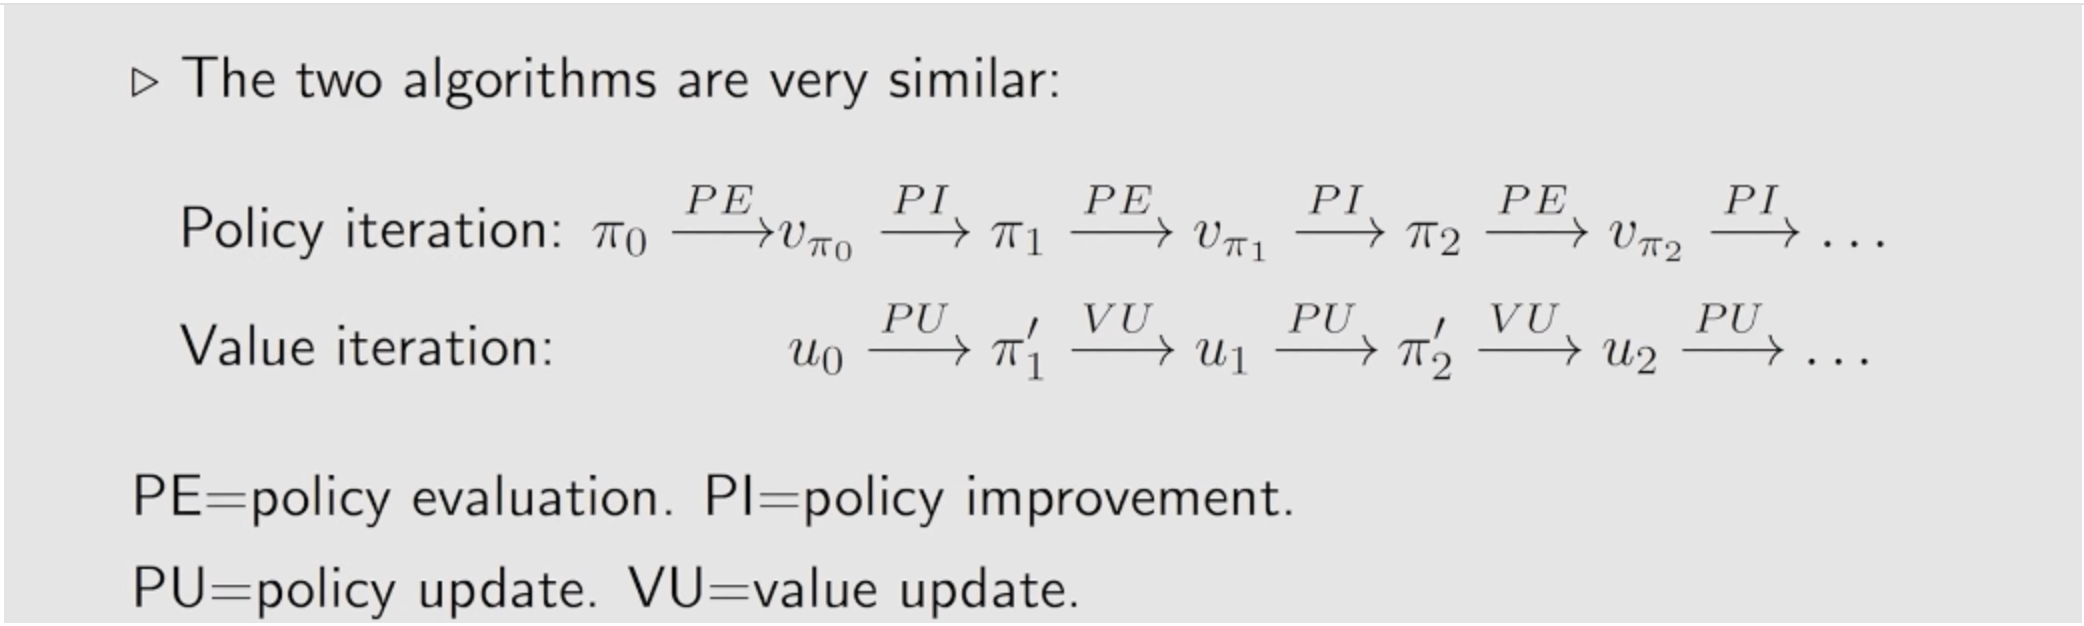

- In policy iteration, solving $v_{\pi_1} = r_{\pi_1} + \gamma P_{\pi_1} v_{\pi_1}$ requires iterative algorithm (an infinite number of iterations)

- Whereas, in value iteration, solving $v_{\pi_1} = r_{\pi_1} + \gamma P_{\pi_1} v_{\pi_0}$ is a one-step iteration

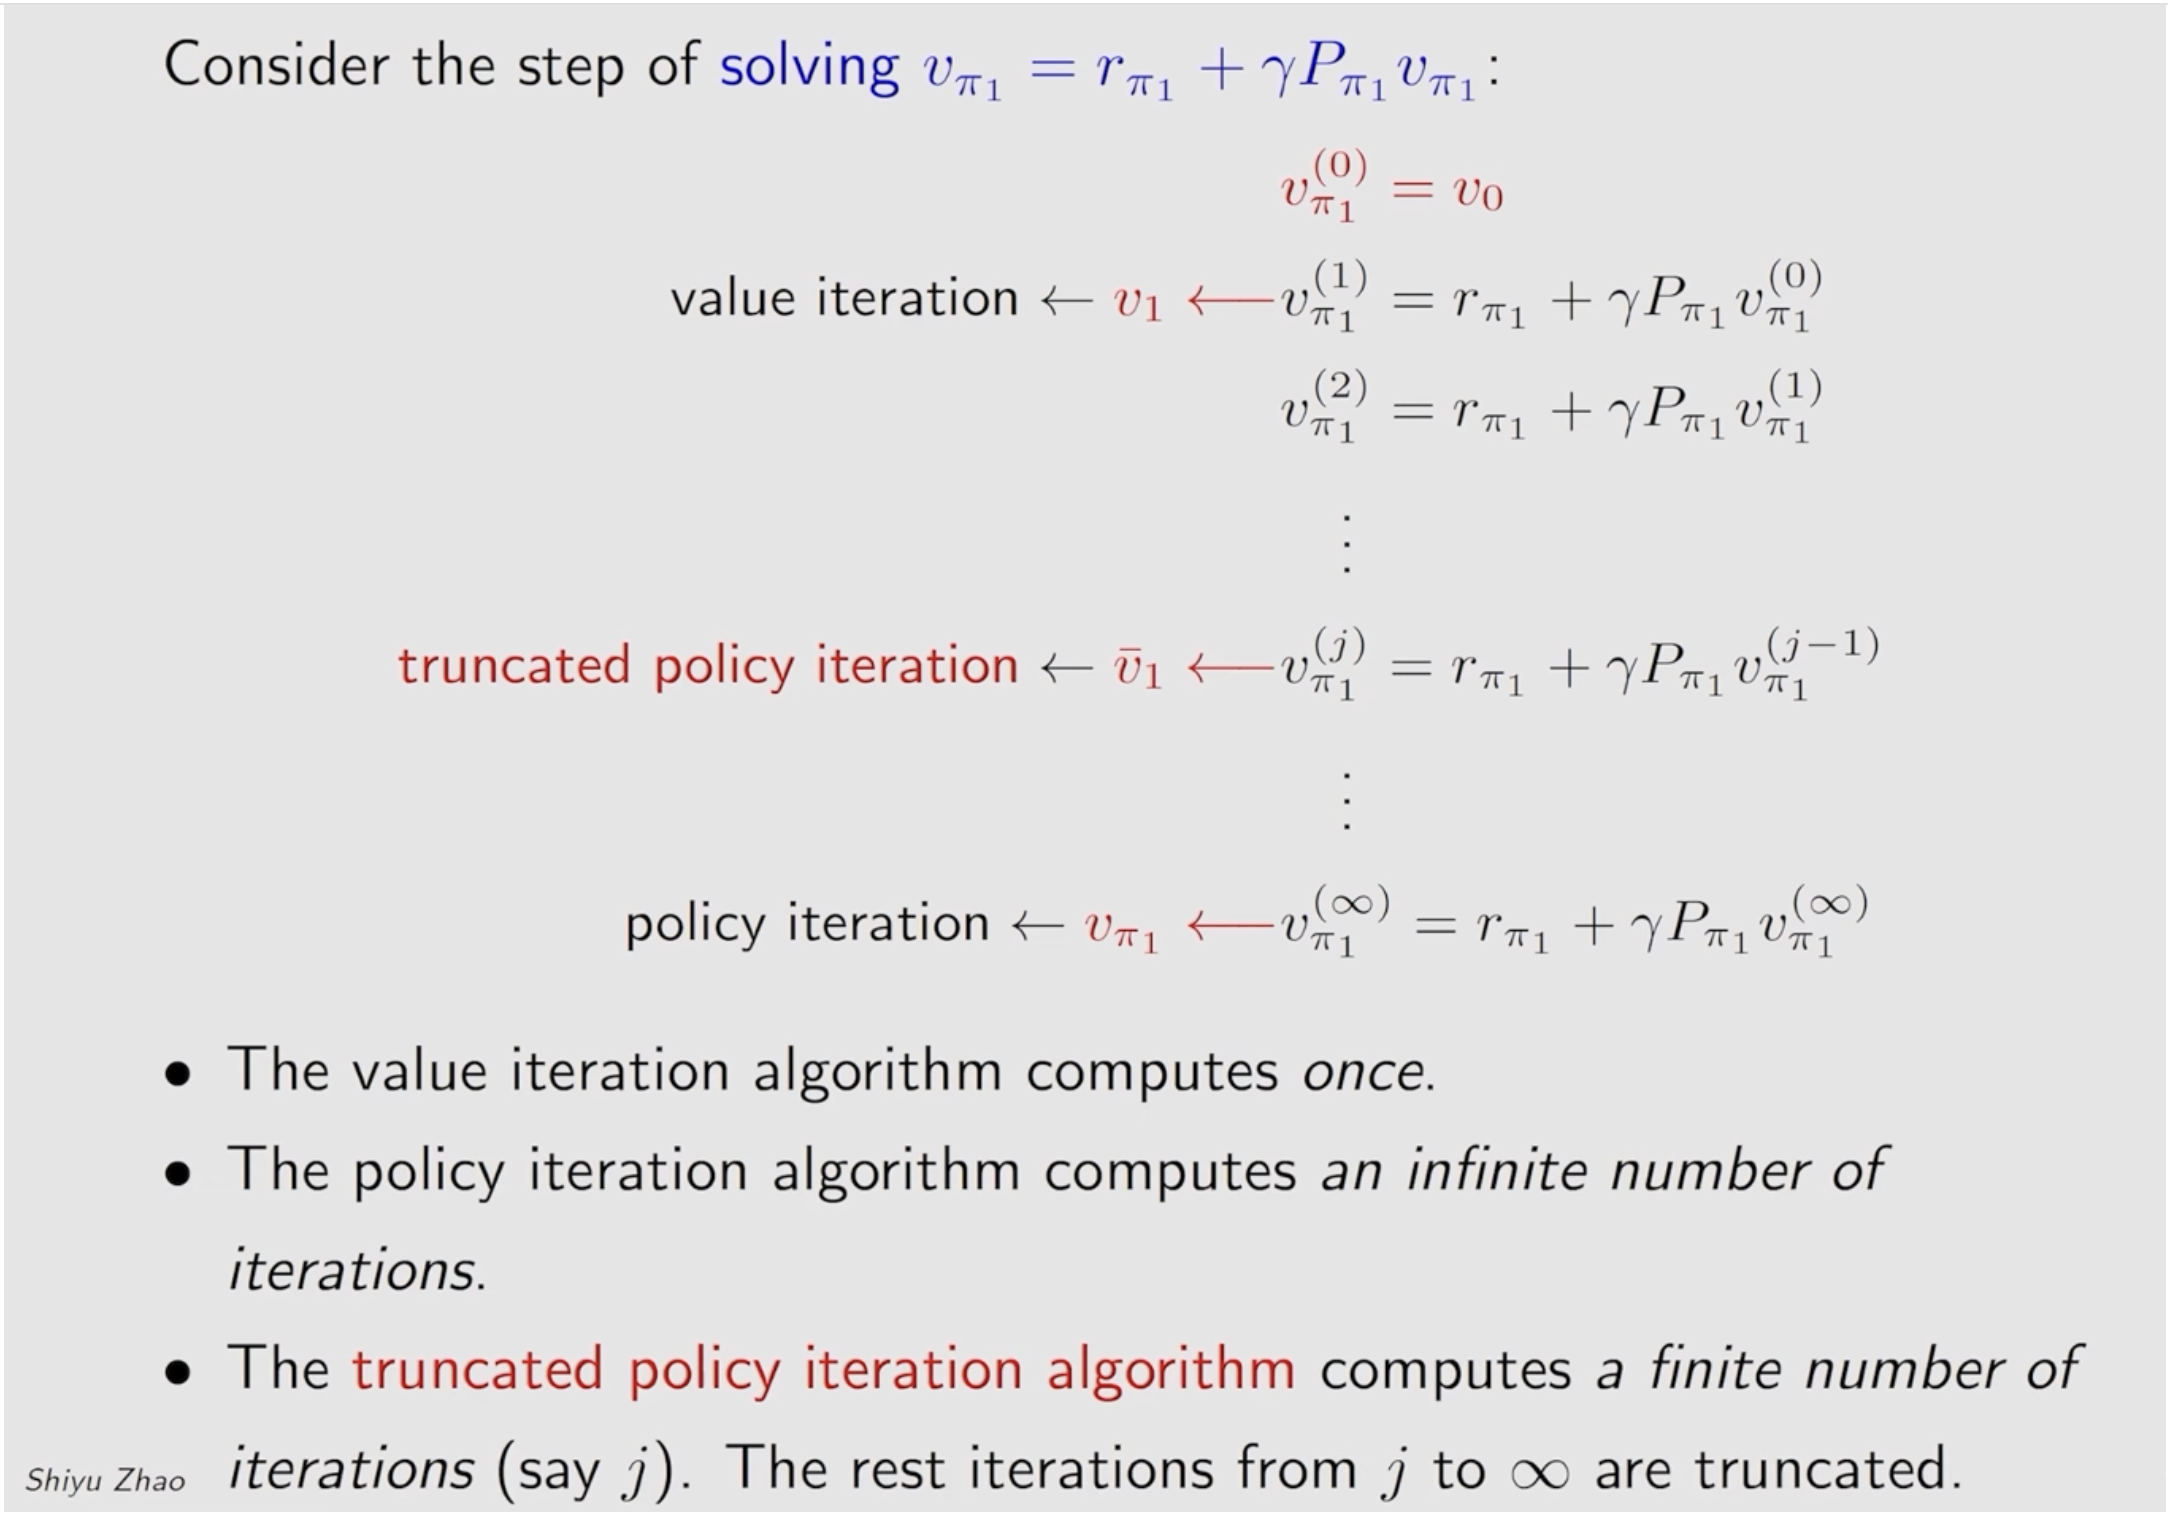

In [4]:
def policy_evaluation(environment, policy, V, j=10, gamma=0.99, theta=1e-10):
    for _ in range(j):
        delta = 0
        for r in range(len(V)):
            for c in range(len(V[0])):
                if environment.grid[r][c] in ["H", "G"]:
                    # terminal states
                    continue
                    
                # state => (r, c)
                action = policy[r][c]
                new_v = 0
                for transition in environment.get_transition_prob((r,c), action):
                    nr, nc = transition["new_state"]
                    new_v += transition["prob"] * (transition["reward"] + gamma * V[nr][nc])
                    
                delta = max(delta, abs(V[r][c] - new_v))
                V[r][c] = new_v
        if delta < theta:
            break
    return V

def policy_improvement(environment, V, gamma=0.99):
    new_policy = np.zeros((environment.n_rows, environment.n_cols), dtype=np.int8)
    for r in range(len(V)):
        for c in range(len(V[0])):
            if environment.grid[r][c] in ["H", "G"]:
                    continue #
            # state = (r, c)
            action_values = []
            
            for action in environment.all_action_idx:
                q = 0
                for transition in environment.get_transition_prob((r, c), action):
                    nr, nc = transition["new_state"]
                    q += transition["prob"] * (transition["reward"] + gamma * V[nr][nc])
                action_values.append(q)
            # pick a greedy action with a highest 
            new_policy[r][c] = np.argmax(action_values).item()
    return new_policy    

In [5]:
n_rows, n_cols = frozen_lake.n_rows, frozen_lake.n_cols

policy = np.zeros((n_rows, n_cols))
V = np.zeros((n_rows, n_cols))
policy

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [6]:
policy_evaluation(frozen_lake, policy, V)

array([[-11.96905741, -12.58879684, -13.27977701, -13.67415888],
       [-12.36824608,   0.        , -10.51439721,   0.        ],
       [-12.24803542,   0.        , -10.10585675,   0.        ],
       [  0.        , -10.06095376,  -8.73765221,   0.        ]])

In [7]:
def truncated_policy_iteration(environment):
    n_rows = environment.n_rows
    n_cols = environment.n_cols
    policy = np.zeros((n_rows, n_cols), dtype=np.int8)
    V = np.zeros((n_rows, n_cols), dtype=np.float32)

    policy_history = [policy.copy()]
    V_history = [V.copy()]
    # j = 1 # acts as a value iteration
    # j = 100000000000000000 # acts as a policy iteration
    j = 2 # 1 < k < inf acts as a truncated policy iteration
    while True:
        V = policy_evaluation(environment, policy, V, j=j)
        new_policy = policy_improvement(environment, V)
        if np.array_equal(policy, new_policy):
            break
            
        policy = new_policy
        policy_history.append(policy.copy())
        V_history.append(V.copy())
        
    return policy, V, policy_history, V_history

In [8]:
policy_evaluation(frozen_lake, policy, V)

array([[-19.30248755, -18.93302839, -18.8427325 , -18.56519357],
       [-16.36384849,   0.        , -11.07104604,   0.        ],
       [-14.15391715,   0.        , -10.16168754,   0.        ],
       [  0.        , -10.06176279,  -8.74446266,   0.        ]])

In [9]:
def truncated_policy_iteration(environment):
    n_rows = environment.n_rows
    n_cols = environment.n_cols
    policy = np.zeros((n_rows, n_cols), dtype=np.int8)
    V = np.zeros((n_rows, n_cols), dtype=np.float32)

    policy_history = [policy.copy()]
    V_history = [V.copy()]
    # j = 1 # acts as a value iteration
    # j = 100000000000000000 # acts as a policy iteration
    j = 2 # 1 < k < inf acts as a truncated policy iteration
    while True:
        V = policy_evaluation(environment, policy, V, j=j)
        new_policy = policy_improvement(environment, V)
        if np.array_equal(policy, new_policy):
            break
            
        policy = new_policy
        policy_history.append(policy.copy())
        V_history.append(V.copy())
        
    return policy, V, policy_history, V_history

In [10]:
# run the policy iteration function to find the best greedy policy
policy, V, policy_history, V_history = truncated_policy_iteration(frozen_lake)

let's do the sanity test of policy_evaluation() implementatation to make sure there is no syntax error

In [11]:
len(policy_history)

8

In [12]:
policy

array([[2, 2, 1, 0],
       [3, 0, 1, 0],
       [3, 0, 1, 0],
       [0, 2, 2, 0]], dtype=int8)

In [13]:
text_policy = []
for r in range(policy.shape[0]):
    col = []
    for c in range(policy.shape[1]):
        col.append(frozen_lake.action_idx_to_name[policy[r][c].item()])
    text_policy.append(col)

In [14]:
text_policy

[['right', 'right', 'down', 'left'],
 ['up', 'left', 'down', 'left'],
 ['up', 'left', 'down', 'left'],
 ['left', 'right', 'right', 'left']]

# Render policy
Let's create a rendering function to visualize the policy clearly.m

In [15]:
render_policy_and_value(frozen_lake, policy, V)

Policy:


,0,1,2,3
0,→,→,↓,←
1,↑,🕳️,↓,🕳️
2,↑,🕳️,↓,🕳️
3,🕳️,→,→,🏁


State-Value Function:


,0,1,2,3
0,-7.00,-5.39,-3.25,-5.18
1,-8.58,0.00,-1.27,0.00
2,-9.72,0.00,2.67,0.00
3,0.00,3.10,8.07,0.00


In [16]:
# Animate policy and state value history

In [17]:
from IPython.display import HTML

In [18]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())

In [19]:
# Let Play with different grid setup

In [20]:
grid = generate_grid_randomly(10, 10, n_holes=10)
grid

[['H', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['G', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'H', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'H', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'S', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'F']]

In [21]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=False)
policy, V, policy_history, V_history = truncated_policy_iteration(frozen_lake)

In [22]:
len(policy_history)

11

In [23]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())